# Go/No-Go 2 readiness audit

## tl;dr

- The frozen pilot dataset contains 10 cases from 10 manufacturers, with 127
  resolvable mesh references and 60 common renders.
- The evaluator gives exact oracle scores and worsens across geometry,
  assembly, kinematics, and motion under deterministic corruption.
- The SOTA comparison is **INCONCLUSIVE**: all 40 required method-case records
  are `NOT_RUN`, not model failures.

## Context & Methods

This notebook audits experiment readiness, not SOTA performance. The denominator
is 10 cases for each of four baselines. Missing credentials or official code are
kept as `NOT_RUN` and never converted to zeros.

### Key Assumptions

- Go/No-Go 1 commit `7b01d43` is the frozen upstream source.
- `protocol.md` v1 is fixed before baseline outputs are inspected.
- A GO/NO-GO decision requires all four methods to have 10 terminal records.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
if root.name == "notebooks":
    root = root.parents[1]
manifest_path = root / "go_nogo2" / "manifests" / "pilot10_manifest.csv"
status_path = root / "go_nogo2" / "results" / "run_status.csv"
summary_path = root / "go_nogo2" / "results" / "summary.json"
manifest = pd.read_csv(manifest_path)
status = pd.read_csv(status_path)
summary = json.loads(summary_path.read_text(encoding="utf-8"))

## Data

### 1. Validate the frozen denominator and case assets

In [2]:
assert len(manifest) == 10
assert manifest.case_id.nunique() == 10
assert manifest.manufacturer.nunique() == 10
assert len(status) == 40
assert set(status.method) == {
    "direct_frontier_mllm", "cadir_simplecad", "articad", "assemcad"
}
assert status.groupby("method").size().eq(10).all()

asset_counts = []
for row in manifest.itertuples():
    case_dir = root / "go_nogo2" / "data" / "pilot10" / row.case_id
    asset_counts.append({
        "case_id": row.case_id,
        "manufacturer": row.manufacturer,
        "mesh_files": len(list((case_dir / "meshes").iterdir())),
        "renders": len(list((case_dir / "renders").glob("*.png"))),
        "urdf": (case_dir / "urdf" / "model.urdf").is_file(),
        "kinematic_gt": (case_dir / "kinematic_gt.json").is_file(),
    })
assets = pd.DataFrame(asset_counts)
assert assets.renders.eq(6).all() and assets.urdf.all() and assets.kinematic_gt.all()
assets

,case_id,manufacturer,mesh_files,renders,urdf,kinematic_gt
0,case_01_arm-fdadfa8bdd,ABB,14,6,True,True
1,case_02_arm-4c7b408826,Fanuc,14,6,True,True
2,case_03_arm-43fa322555,Franka Emika,16,6,True,True
3,case_04_arm-dcc2b0ce1e,KUKA,14,6,True,True
4,case_05_arm-ab15a75247,Lynxmotion,5,6,True,True
5,case_06_arm-42e898b1a2,Mecademic Robotics,14,6,True,True
6,case_07_arm-10f5f05385,Quanser,5,6,True,True
7,case_08_arm-d55f01b988,ROBOTIS,7,6,True,True
8,case_09_arm-551a9c392e,Rethink Robotics,10,6,True,True
9,case_10_arm-21b8992ec4,Schunk,13,6,True,True


## Results

### 2. Run coverage is blocked, not poor performance

run_status,NOT_RUN
method,
direct_frontier_mllm,10
cadir_simplecad,10
articad,10
assemcad,10


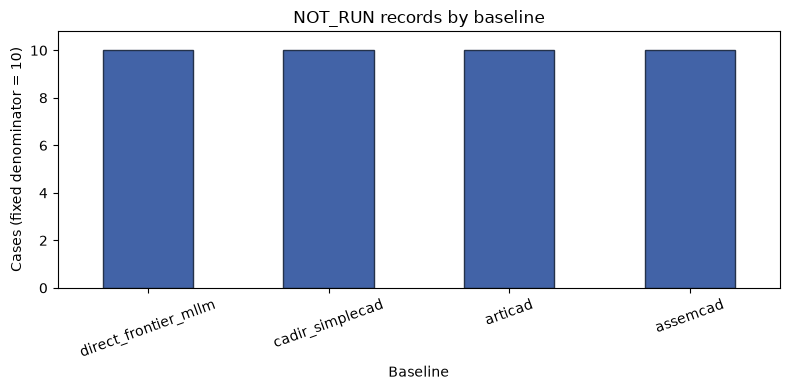

In [3]:
coverage = (
    status.groupby(["method", "run_status"]).size().unstack(fill_value=0)
    .reindex(["direct_frontier_mllm", "cadir_simplecad", "articad", "assemcad"])
)
assert coverage.get("NOT_RUN", pd.Series(dtype=int)).eq(10).all()
ax = coverage[["NOT_RUN"]].plot.bar(
    color="#4263a7", edgecolor="#24324a", figsize=(8, 4), legend=False
)
ax.set_title("NOT_RUN records by baseline")
ax.set_subtitle = None
ax.set_xlabel("Baseline")
ax.set_ylabel("Cases (fixed denominator = 10)")
ax.set_ylim(0, 10.8)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
coverage

### 3. Re-run the evaluator oracle/corruption validation

In [4]:
validation_script = root / "go_nogo2" / "scripts" / "validate_evaluator.py"
completed = subprocess.run(
    [sys.executable, str(validation_script)], cwd=root,
    check=True, capture_output=True, text=True,
)
validation = json.loads(
    (root / "go_nogo2" / "runs" / "evaluator_validation" / "validation_report.json")
    .read_text(encoding="utf-8")
)
assert validation["oracle"]["outcome"]["simultaneous_success"] is True
assert validation["corrupted"]["outcome"]["simultaneous_success"] is False
completed.stdout.strip(), validation["corrupted"]["outcome"]["failure_patterns"]

('PASS: oracle exactness, corruption directions, and common run contract',
 ['missing_parts',
  'poor_curved_geometry',
  'poor_geometry',
  'wrong_joint_axis',
  'wrong_joint_origin',
  'wrong_joint_type',
  'wrong_motion'])

## Takeaways

1. Dataset construction and deterministic evaluation are feasible and
   reproducible in the paper-wide `.venv`.
2. No SOTA-performance statement is currently supported because zero baselines
   have a complete 10-case run.
3. The next executable step is to supply `OPENAI_API_KEY` for Direct and CADIR;
   ArtiCAD and AssemCAD additionally need official runnable implementations.
4. Until all four methods are comparable, the frozen decision remains
   **INCONCLUSIVE**.